## Pratyush Barman and Simran Khare
DEEP LEARNING ASSIGNMENT 1

In [44]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# Display plots inline
%matplotlib inline

## Task 1 - Logistic Reg

In [46]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def calculate_gradient_single(theta, x_b, y_single):
    """Calculate gradient for a single training example"""
    y_hat = sigmoid(x_b @ theta)
    gradient = x_b.T * (y_hat - y_single)
    return gradient

def stochastic_gradient_descent(X, y, alpha=0.1, num_epochs=100, tol=1e-7, random_seed=42):
    np.random.seed(random_seed)

    X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add bias term
    theta = np.zeros(X_b.shape[1])
    m = X.shape[0]

    cost_history = []

    for epoch in range(num_epochs):
        # Shuffle the data at the start of each epoch
        indices = np.random.permutation(m)
        X_b_shuffled = X_b[indices]
        y_shuffled = y[indices]

        # Update theta for each training example
        for i in range(m):
            x_i = X_b_shuffled[i]  # Single training example
            y_i = y_shuffled[i]

            # Calculate gradient for this single example
            grad = calculate_gradient_single(theta, x_i, y_i)

            # Update parameters
            theta -= alpha * grad

        # Compute cost on entire dataset after each epoch (for monitoring)
        cost = compute_cost(theta, X_b, y)
        cost_history.append(cost)

        # Check for convergence (based on cost change)
        if epoch > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:
            print(f"Converged at epoch {epoch}")
            break

    return theta, cost_history

def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

def compute_cost(theta, X_b, y):
    m = y.size
    y_hat = sigmoid(X_b @ theta)
    eps = 1e-9
    cost = -(1 / m) * np.sum(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )
    return cost

## Dataset 1 - Blobs 3D

The dimensions of the dataset are: (600, 3)


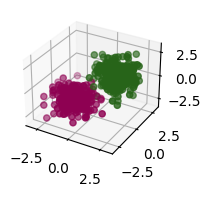

In [47]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

# Check its dimensions
print(f"The dimensions of the dataset are: {np.shape(X1)}")

# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(2, 2)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

## Dataset 2 - Circles 2D

The dimensions of Dataset 2 are: (500, 2)


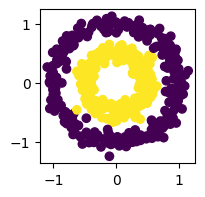

In [48]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

# Check its dimensions
print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

# plot X[0] vs X[1] and colour points according to the class, y
fig, ax = plt.subplots(figsize=(2, 2))
ax.scatter(X2[:,0], X2[:,1], c=y2)
plt.show()
plt.close(fig)

## Examine Data

In [49]:
# Some examples of working with the data, to look at rows/columns
print ("len(X2):", len(X2))            # outer array: one per sample
print ("len(X2[0]):", len(X2[0]))      # each inner array is the attributes of one sample
print ("len(X2[:,0]):", len(X2[:,0]))  # select column 0 from array

# np.shape returns all dimensions of the array
(nsamples, nattribs) = np.shape(X2)
print ("X2: nsamples =", nsamples, ", nattribs =", nattribs)

# Now example the y vector (1D array)
print ("len(y2)", len(y2))
print ("np.shape(y2):", np.shape(y2))

# You can transpose the y data using 'reshape'
yt = np.reshape(y2, (len(y2),1))
print ("np.shape(yt):", np.shape(yt))
(nsamples, nattribs) = np.shape(yt)
print ("y2 transpose: nsamples =", nsamples, ", nattribs =", nattribs)

len(X2): 500
len(X2[0]): 2
len(X2[:,0]): 500
X2: nsamples = 500 , nattribs = 2
len(y2) 500
np.shape(y2): (500,)
np.shape(yt): (500, 1)
y2 transpose: nsamples = 500 , nattribs = 1


## Task 2 Testing

In [50]:
def split_dataset(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    indices = np.random.permutation(m)

    train_end = int(train_ratio * m)
    val_end = int((train_ratio + val_ratio) * m)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [51]:
# Dataset 1 (3D, blobs)
X1_train, y1_train, X1_val, y1_val, X1_test, y1_test = split_dataset(X1, y1)

# Dataset 2 (2D, circles)
X2_train, y2_train, X2_val, y2_val, X2_test, y2_test = split_dataset(X2, y2)


In [52]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [53]:
learning_rates = [0.001, 0.01, 0.1, 0.5]  # May need lower LRs for SGD
num_epochs = 100  # Number of passes through the dataset

print("=== Tuning Dataset 1 (Blobs) - Stochastic GD ===")
best_lr_1 = None
best_acc_1 = 0
best_cost_1 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X1_train, y1_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X1_val, theta)
    acc = accuracy(y1_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_1 or (acc == best_acc_1 and final_cost < best_cost_1):
        best_acc_1 = acc
        best_lr_1 = lr
        best_cost_1 = final_cost

print(f"\nDataset 1 best learning rate: {best_lr_1}, Best Val Acc: {best_acc_1:.4f}, Best Cost: {best_cost_1:.4f}")

# Tune learning rate for Dataset 2
print("\n=== Tuning Dataset 2 (Circles) - Stochastic GD ===")
best_lr_2 = None
best_acc_2 = 0
best_cost_2 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X2_train, y2_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_2 or (acc == best_acc_2 and final_cost < best_cost_2):
        best_acc_2 = acc
        best_lr_2 = lr
        best_cost_2 = final_cost

print(f"\nDataset 2 best learning rate: {best_lr_2}, Best Val Acc: {best_acc_2:.4f}, Best Cost: {best_cost_2:.4f}")

=== Tuning Dataset 1 (Blobs) - Stochastic GD ===
LR=0.001: Validation Acc=1.0000, Final Cost=0.0284
LR=0.01: Validation Acc=1.0000, Final Cost=0.0135
LR=0.1: Validation Acc=1.0000, Final Cost=0.0111
LR=0.5: Validation Acc=1.0000, Final Cost=0.0110

Dataset 1 best learning rate: 0.5, Best Val Acc: 1.0000, Best Cost: 0.0110

=== Tuning Dataset 2 (Circles) - Stochastic GD ===
LR=0.001: Validation Acc=0.5200, Final Cost=0.6915
LR=0.01: Validation Acc=0.5467, Final Cost=0.6915
LR=0.1: Validation Acc=0.5067, Final Cost=0.6923
LR=0.5: Validation Acc=0.6133, Final Cost=0.7048

Dataset 2 best learning rate: 0.5, Best Val Acc: 0.6133, Best Cost: 0.7048


In [54]:
# Tune learning rate for Dataset 2

print("\n=== Tuning Dataset 2 (Circles) - Stochastic GD ===")
best_lr_2 = None
best_acc_2 = 0
best_cost_2 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X2_train, y2_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_2 or (acc == best_acc_2 and final_cost < best_cost_2):
        best_acc_2 = acc
        best_lr_2 = lr
        best_cost_2 = final_cost

print(f"\nDataset 2 best learning rate: {best_lr_2}, Best Val Acc: {best_acc_2:.4f}, Best Cost: {best_cost_2:.4f}")


=== Tuning Dataset 2 (Circles) - Stochastic GD ===
LR=0.001: Validation Acc=0.5200, Final Cost=0.6915
LR=0.01: Validation Acc=0.5467, Final Cost=0.6915
LR=0.1: Validation Acc=0.5067, Final Cost=0.6923
LR=0.5: Validation Acc=0.6133, Final Cost=0.7048

Dataset 2 best learning rate: 0.5, Best Val Acc: 0.6133, Best Cost: 0.7048


In [55]:
# Train final models and evaluate on test set
print("\n=== Final Test Results ===")
theta1, cost_history1 = stochastic_gradient_descent(X1_train, y1_train, alpha=best_lr_1, num_epochs=num_epochs)
test_preds_1 = predict(X1_test, theta1)
test_acc_1 = accuracy(y1_test, test_preds_1)
print(f"Dataset 1 Test Accuracy: {test_acc_1:.4f}")

theta2, cost_history2 = stochastic_gradient_descent(X2_train, y2_train, alpha=best_lr_2, num_epochs=num_epochs)
test_preds_2 = predict(X2_test, theta2)
test_acc_2 = accuracy(y2_test, test_preds_2)
print(f"Dataset 2 Test Accuracy: {test_acc_2:.4f}")



=== Final Test Results ===
Dataset 1 Test Accuracy: 1.0000
Dataset 2 Test Accuracy: 0.5200


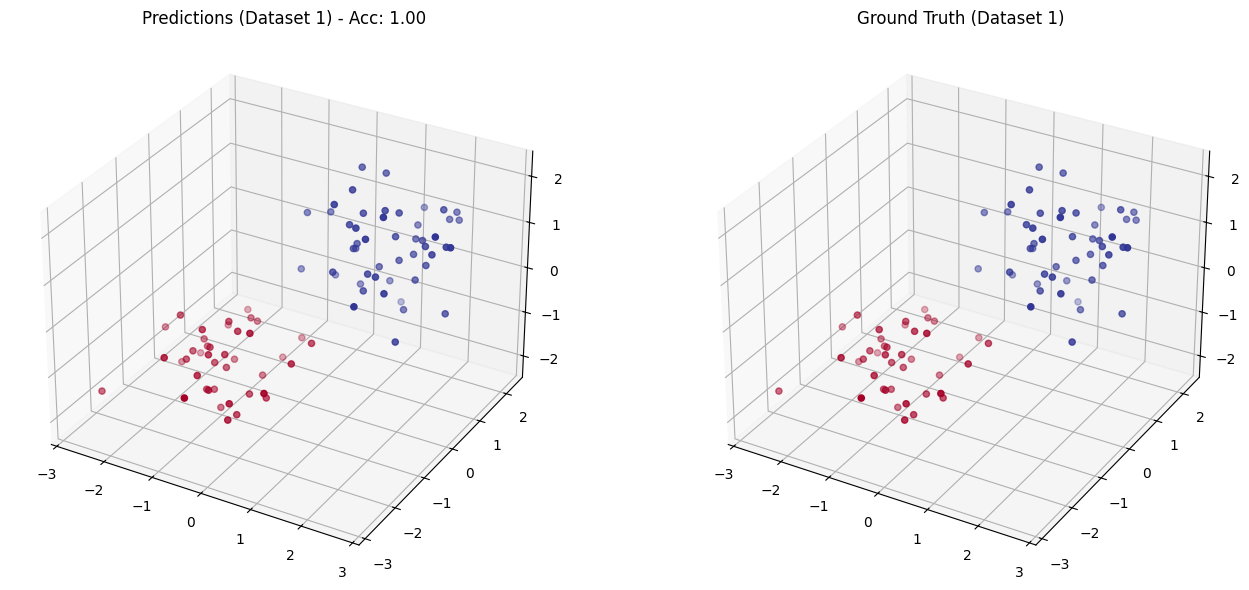

In [56]:
# Plot predictions for Dataset 1
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X1_test[:, 0], X1_test[:, 1], X1_test[:, 2], c=test_preds_1, cmap="RdYlBu")
ax1.set_title(f"Predictions (Dataset 1) - Acc: {test_acc_1:.2f}")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X1_test[:, 0], X1_test[:, 1], X1_test[:, 2], c=y1_test, cmap="RdYlBu")
ax2.set_title("Ground Truth (Dataset 1)")

plt.tight_layout()
plt.show()

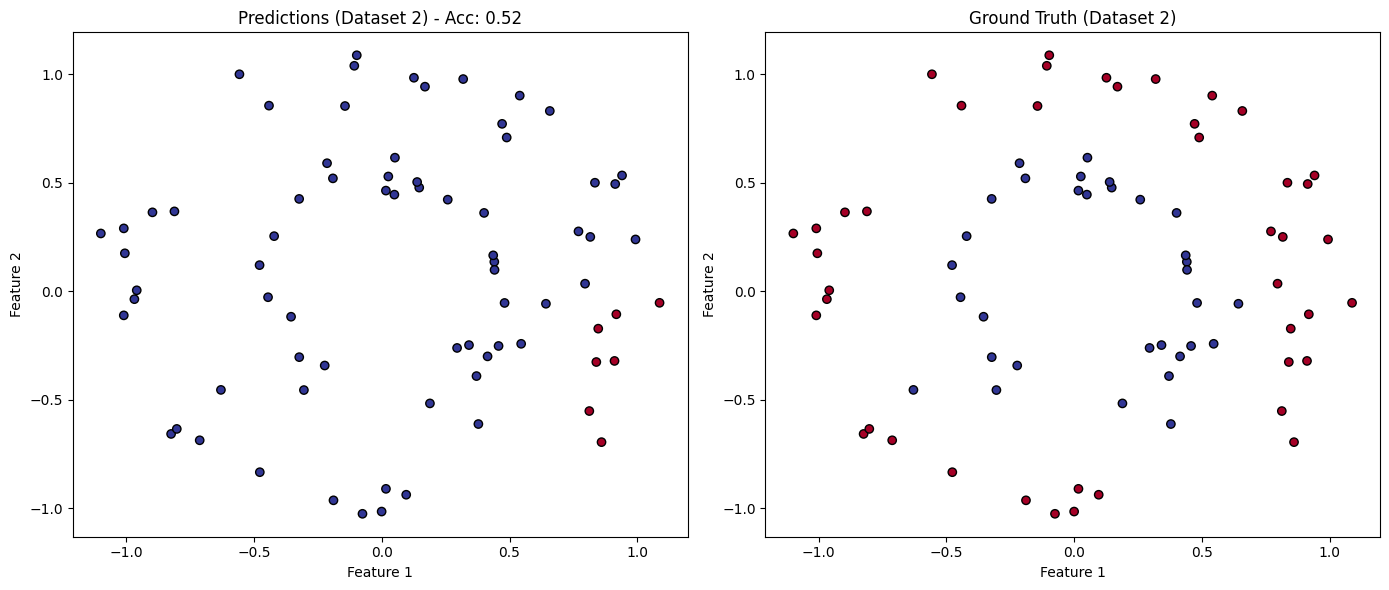

In [57]:
# Plot predictions for Dataset 2
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
 # Predictions
ax[0].scatter(X2_test[:, 0], X2_test[:, 1], c=test_preds_2, cmap="RdYlBu", edgecolors="k")
ax[0].set_title(f"Predictions (Dataset 2) - Acc: {test_acc_2:.2f}")
ax[0].set_xlabel("Feature 1")
ax[0].set_ylabel("Feature 2")

# Ground truth
ax[1].scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, cmap="RdYlBu", edgecolors="k")
ax[1].set_title("Ground Truth (Dataset 2)")
ax[1].set_xlabel("Feature 1")
ax[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

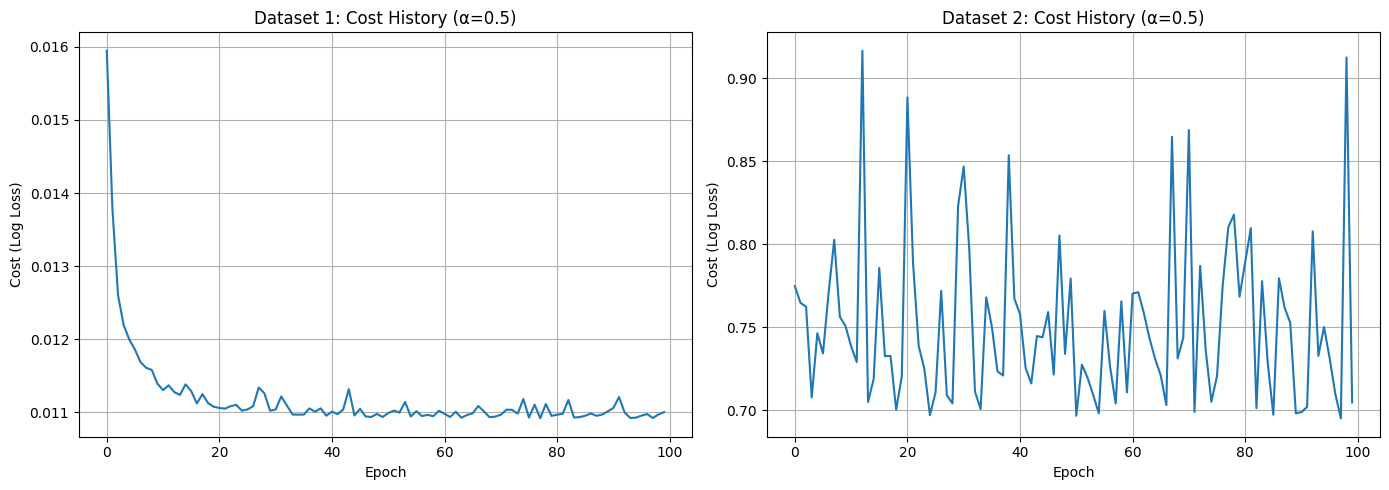

In [58]:
# Plot cost history (per epoch)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(len(cost_history1)), cost_history1)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Cost (Log Loss)")
ax[0].set_title(f"Dataset 1: Cost History (α={best_lr_1})")
ax[0].grid(True)

ax[1].plot(range(len(cost_history2)), cost_history2)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Cost (Log Loss)")
ax[1].set_title(f"Dataset 2: Cost History (α={best_lr_2})")
ax[1].grid(True)

plt.tight_layout()
plt.show()

##TASK 3

In [59]:
class ShallowNeuralNetwork:
    def __init__(self,n_features,n_hidden,learning_rate=0.1,random_seed=42):
        np.random.seed(random_seed)
        self.n_features=n_features
        self.n_hidden=n_hidden
        self.learning_rate=learning_rate
        self.W1=np.random.randn(n_features,n_hidden)*0.01
        self.b1=np.zeros((1,n_hidden))
        self.W2=np.random.randn(n_hidden,1)*0.01
        self.b2=np.zeros((1,1))
        self.cost_history=[]

    def sigmoid(self,z):
        return 1/(1+np.exp(-np.clip(z,-500,500)))

    def forward_propagation(self,X):
        if len(X.shape)==1:
            X=X.reshape(1,-1)
        Z1=X@self.W1+self.b1
        A1=self.sigmoid(Z1)
        Z2=A1@self.W2+self.b2
        A2=self.sigmoid(Z2)
        cache={"X":X,"A1":A1,"A2":A2}
        return A2,cache

    def backward_propagation(self,y,cache):
        X=cache["X"]
        A1=cache["A1"]
        A2=cache["A2"]
        if isinstance(y,(int,float,np.integer,np.floating)):
            y=np.array([[y]])
        elif len(y.shape)==1:
            y=y.reshape(-1,1)
        dZ2=A2-y
        dW2=A1.T@dZ2
        db2=dZ2
        dA1=dZ2@self.W2.T
        dZ1=dA1*A1*(1-A1)
        dW1=X.T@dZ1
        db1=dZ1
        return {"dW1":dW1,"db1":db1,"dW2":dW2,"db2":db2}

    def update_parameters(self,g):
        self.W1-=self.learning_rate*g["dW1"]
        self.b1-=self.learning_rate*g["db1"]
        self.W2-=self.learning_rate*g["dW2"]
        self.b2-=self.learning_rate*g["db2"]

    def train(self,X,y,num_epochs=100):
        m=X.shape[0]
        self.cost_history=[]
        for epoch in range(num_epochs):
            idx=np.random.permutation(m)
            Xs=X[idx]
            ys=y[idx]
            for i in range(m):
                A2,cache=self.forward_propagation(Xs[i])
                g=self.backward_propagation(ys[i],cache)
                self.update_parameters(g)
            A2_all,_=self.forward_propagation(X)
            eps=1e-9
            y_col=y.reshape(-1,1)
            cost=-np.mean(y_col*np.log(A2_all+eps)+(1-y_col)*np.log(1-A2_all+eps))
            self.cost_history.append(cost)

    def predict_proba(self,X):
        A2,_=self.forward_propagation(X)
        return A2.flatten()

    def predict(self,X,threshold=0.5):
        return (self.predict_proba(X)>=threshold).astype(int)


In [60]:
learning_rates_nn=[0.01,0.05,0.1,0.5,1.0]
best_lr_nn2=None
best_val_acc_nn2=-1.0

for lr in learning_rates_nn:
    nn_temp=ShallowNeuralNetwork(n_features=X2_train.shape[1],n_hidden=10,learning_rate=lr,random_seed=42)
    nn_temp.train(X2_train,y2_train,num_epochs=300)
    val_acc=float(accuracy(y2_val,nn_temp.predict(X2_val)))
    print(f"LR={lr} Val Acc={val_acc:.4f}")
    if val_acc>best_val_acc_nn2:
        best_val_acc_nn2=val_acc
        best_lr_nn2=lr

results_dataset1=[]
for n_hidden in [2,5,10,15,20]:
    nn=ShallowNeuralNetwork(n_features=X1_train.shape[1],n_hidden=n_hidden,learning_rate=1.0,random_seed=42)
    nn.train(X1_train,y1_train,num_epochs=200)
    test_acc=float(accuracy(y1_test,nn.predict(X1_test)))
    print(f"Blobs {n_hidden} hidden -> Test {test_acc:.4f}")
    results_dataset1.append((n_hidden,test_acc))

results_dataset2=[]
for n_hidden in [2,5,10,15,20]:
    nn=ShallowNeuralNetwork(n_features=X2_train.shape[1],n_hidden=n_hidden,learning_rate=best_lr_nn2,random_seed=42)
    nn.train(X2_train,y2_train,num_epochs=500)
    test_acc=float(accuracy(y2_test,nn.predict(X2_test)))
    print(f"Circles {n_hidden} hidden -> Test {test_acc:.4f}")
    results_dataset2.append((n_hidden,test_acc))

best_blobs=max(results_dataset1,key=lambda x:x[1])
best_circles=max(results_dataset2,key=lambda x:x[1])
print(f"Best Blobs: ({best_blobs[0]}, {best_blobs[1]:.4f})")
print(f"Best Circles: ({best_circles[0]}, {best_circles[1]:.4f})")

LR=0.01 Val Acc=0.3733
LR=0.05 Val Acc=1.0000
LR=0.1 Val Acc=0.4933
LR=0.5 Val Acc=0.5067
LR=1.0 Val Acc=0.9733
Blobs 2 hidden -> Test 0.9889
Blobs 5 hidden -> Test 1.0000
Blobs 10 hidden -> Test 0.9889
Blobs 15 hidden -> Test 0.9778
Blobs 20 hidden -> Test 0.9889
Circles 2 hidden -> Test 0.4267
Circles 5 hidden -> Test 0.4267
Circles 10 hidden -> Test 0.9467
Circles 15 hidden -> Test 0.9467
Circles 20 hidden -> Test 0.9867
Best Blobs: (5, 1.0000)
Best Circles: (20, 0.9867)


##TASK 4 (J,M)

In [61]:
##sir ka code

data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes}")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()}")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape}")
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)
plt.figure(figsize=(12, 6))

#extracting 2 classes
c1 = 10 #j
c2 = 13 #m

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))

    for i in range(48):
        idx = n + i

        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

The number of unique classes is 26

For a single image, the min value is 0.0 and the max is 1.0

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,)


<Figure size 1200x600 with 0 Axes>

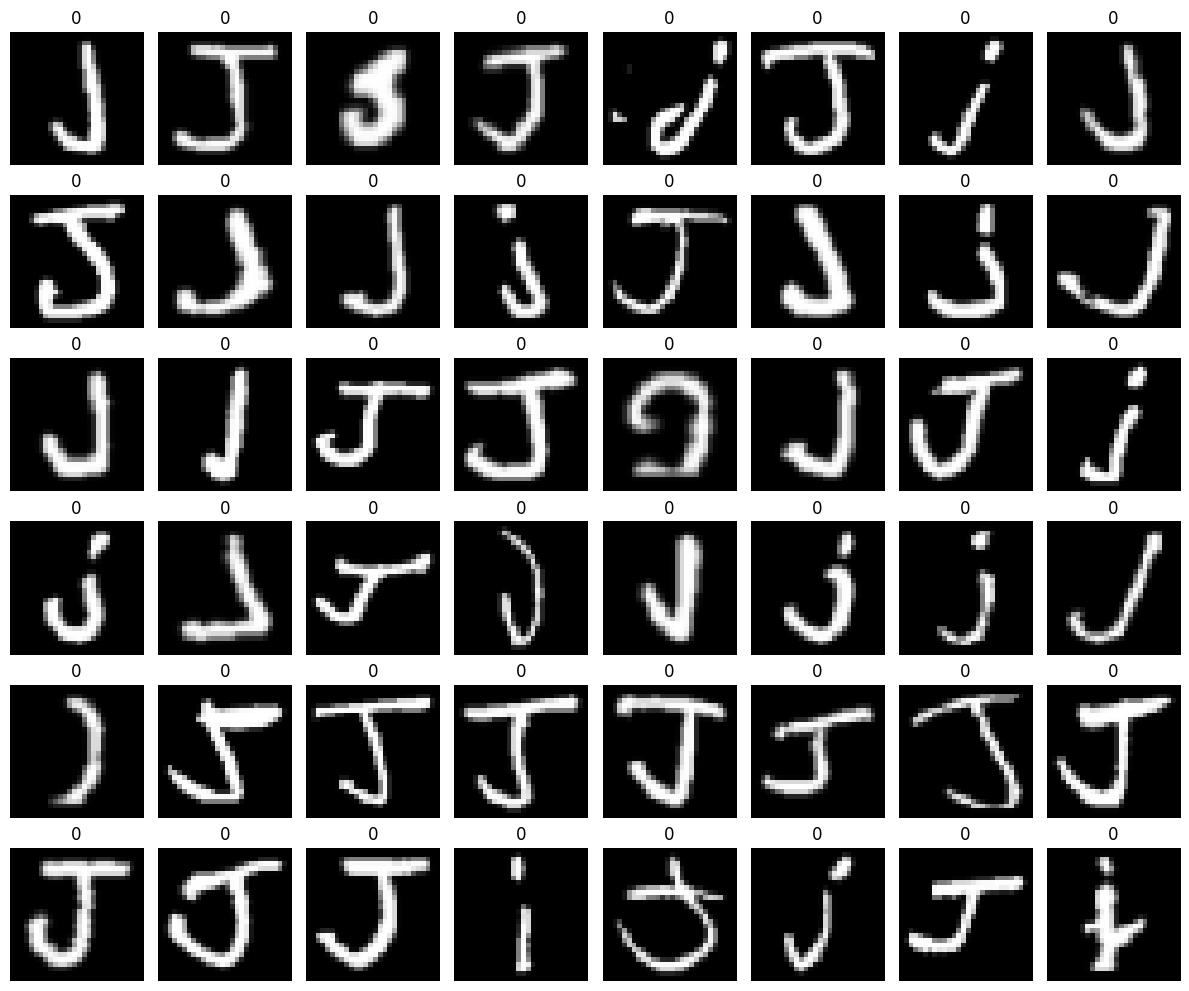

In [62]:
plot_grid(x_binary, y_binary, n=0)

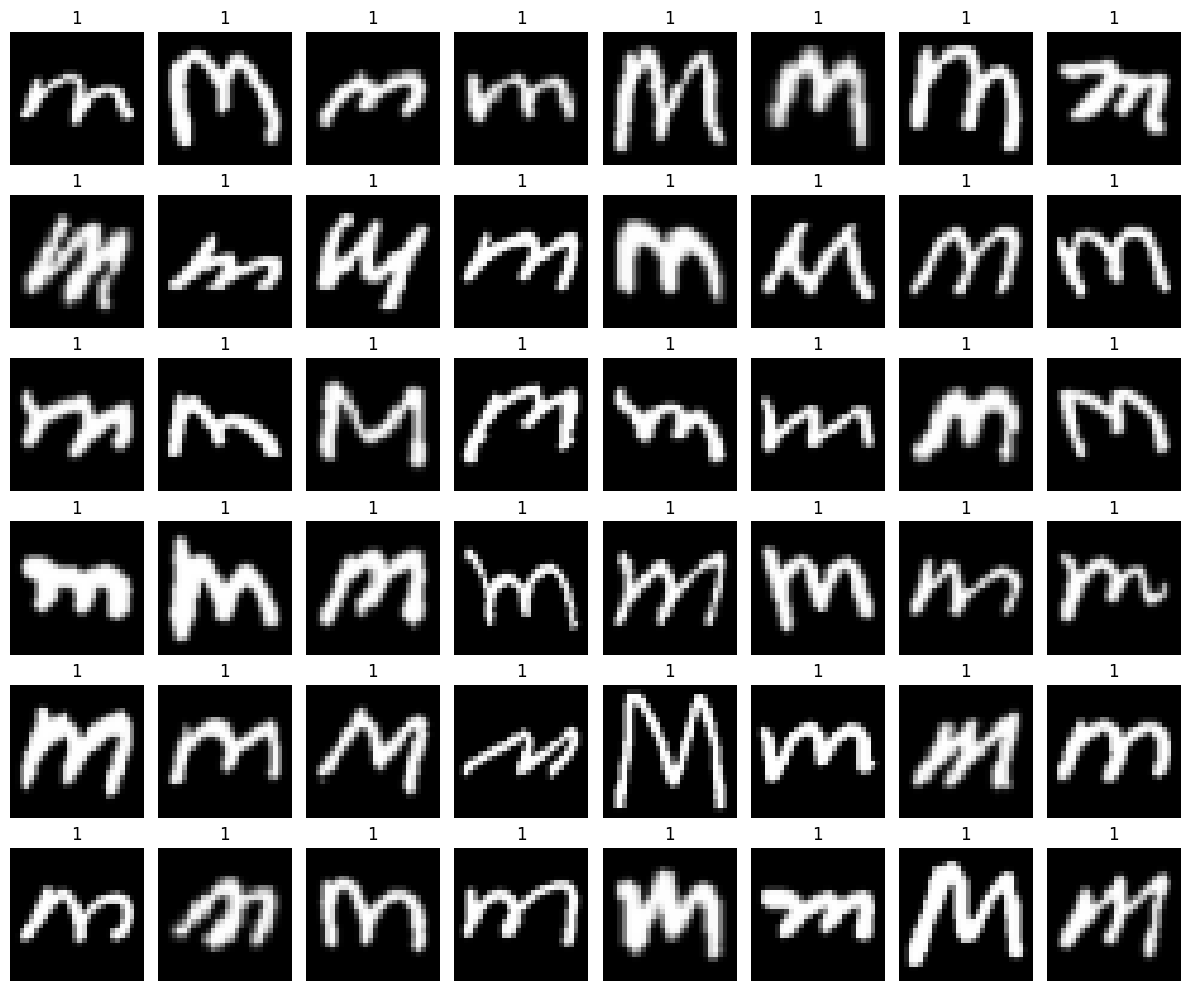

In [63]:
plot_grid(x_binary, y_binary, n=3300)

Total samples (J + M): 6600
J (label=0): 3300,  M (label=1): 3300
Flattened input shape: (6600, 784)


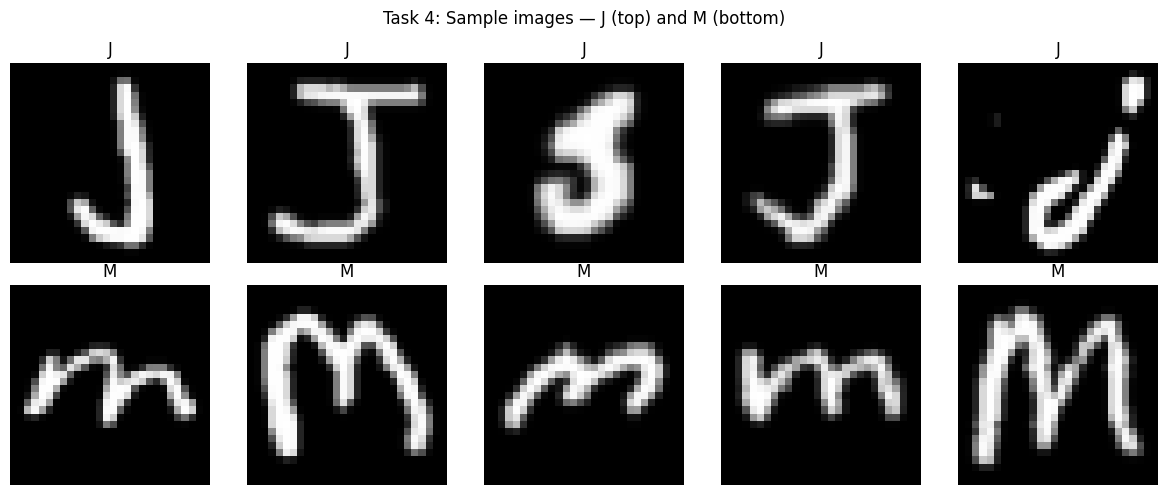

In [64]:
# ============================================================
# TASK 4: SHALLOW NEURAL NETWORK ON EMNIST (J vs M)
# ============================================================

print(f"Total samples (J + M): {len(y_binary)}")
print(f"J (label=0): {np.sum(y_binary == 0)},  M (label=1): {np.sum(y_binary == 1)}")

# ---- Flatten 28x28 images to 784-dimensional vectors ----
x_flat = x_binary.reshape(x_binary.shape[0], -1)   #sir told
print(f"Flattened input shape: {x_flat.shape}")

# ---- Show sample images ----
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
letter_map = {0: 'J', 1: 'M'}
for row, cls in enumerate([0, 1]):
    idxs = np.where(y_binary == cls)[0][:5]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(x_binary[idx].squeeze(), cmap="gray")
        axes[row, col].set_title(letter_map[cls])
        axes[row, col].axis("off")
plt.suptitle("Task 4: Sample images — J (top) and M (bottom)")
plt.tight_layout()
plt.show()


In [65]:
# ---- Train / Validation / Test split: 70% / 15% / 15% ----
np.random.seed(42)
n = len(y_binary)
indices = np.random.permutation(n)

train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

X4_train, y4_train = x_flat[train_idx], y_binary[train_idx]
X4_val,   y4_val   = x_flat[val_idx],   y_binary[val_idx]
X4_test,  y4_test  = x_flat[test_idx],  y_binary[test_idx]

print(f"\nSplit — Train: {len(y4_train)}, Val: {len(y4_val)}, Test: {len(y4_test)}")



Split — Train: 4620, Val: 990, Test: 990


In [66]:
# ---- Patch ShallowNeuralNetwork to use Xavier initialisation ----
# (Your current init uses randn*0.01 which is too small for 784 features)
class ShallowNeuralNetwork:
    def __init__(self, n_features, n_hidden, learning_rate=0.1, random_seed=42):
        np.random.seed(random_seed)
        self.n_features = n_features
        self.n_hidden   = n_hidden
        self.learning_rate = learning_rate

        # Xavier / Glorot initialisation
        limit1 = np.sqrt(6 / (n_features + n_hidden))
        self.W1 = np.random.uniform(-limit1, limit1, (n_features, n_hidden))
        self.b1 = np.zeros((1, n_hidden))

        limit2 = np.sqrt(6 / (n_hidden + 1))
        self.W2 = np.random.uniform(-limit2, limit2, (n_hidden, 1))
        self.b2 = np.zeros((1, 1))

        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward_propagation(self, X):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        Z1 = X @ self.W1 + self.b1
        A1 = self.sigmoid(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = self.sigmoid(Z2)
        cache = {"X": X, "A1": A1, "A2": A2}
        return A2, cache

    def backward_propagation(self, y, cache):
        X  = cache["X"]
        A1 = cache["A1"]
        A2 = cache["A2"]
        if isinstance(y, (int, float, np.integer, np.floating)):
            y = np.array([[y]])
        elif len(y.shape) == 1:
            y = y.reshape(-1, 1)
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2
        db2 = dZ2
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * A1 * (1 - A1)
        dW1 = X.T @ dZ1
        db1 = dZ1
        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

    def update_parameters(self, g):
        self.W1 -= self.learning_rate * g["dW1"]
        self.b1 -= self.learning_rate * g["db1"]
        self.W2 -= self.learning_rate * g["dW2"]
        self.b2 -= self.learning_rate * g["db2"]

    def train(self, X, y, num_epochs=100):
        m = X.shape[0]
        self.cost_history = []
        for epoch in range(num_epochs):
            idx = np.random.permutation(m)
            Xs  = X[idx]
            ys  = y[idx]
            for i in range(m):
                A2, cache = self.forward_propagation(Xs[i])
                g = self.backward_propagation(ys[i], cache)
                self.update_parameters(g)
            A2_all, _ = self.forward_propagation(X)
            eps   = 1e-9
            y_col = y.reshape(-1, 1)
            cost  = -np.mean(y_col * np.log(A2_all + eps) + (1 - y_col) * np.log(1 - A2_all + eps))
            self.cost_history.append(cost)
            if epoch % 5 == 0:
                preds    = self.predict(X)
                train_acc = accuracy(y, preds)
                print(f"  Epoch {epoch:>3} — Cost: {cost:.4f}  Train Acc: {train_acc:.4f}")

    def predict_proba(self, X):
        A2, _ = self.forward_propagation(X)
        return A2.flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [67]:
# ---- Tune learning rate (hidden=64, 5 epochs each for speed) ----
print("\n--- Tuning Learning Rate ---")
learning_rates_t4 = [0.001, 0.005, 0.01, 0.05, 0.1]
best_lr_t4      = None
best_val_acc_t4 = 0

for lr in learning_rates_t4:
    nn_tmp = ShallowNeuralNetwork(
        n_features=X4_train.shape[1],
        n_hidden=64,
        learning_rate=lr,
        random_seed=42
    )
    nn_tmp.train(X4_train, y4_train, num_epochs=5)
    val_preds  = nn_tmp.predict(X4_val)
    val_acc    = accuracy(y4_val, val_preds)
    final_cost = nn_tmp.cost_history[-1]
    print(f"  LR={lr}: Val Acc={val_acc:.4f}, Final Cost={final_cost:.4f}")

    if val_acc > best_val_acc_t4:
        best_val_acc_t4 = val_acc
        best_lr_t4      = lr

print(f"\nBest learning rate: {best_lr_t4}")


--- Tuning Learning Rate ---
  Epoch   0 — Cost: 0.1393  Train Acc: 0.9877
  LR=0.001: Val Acc=0.9899, Final Cost=0.0364
  Epoch   0 — Cost: 0.0365  Train Acc: 0.9920
  LR=0.005: Val Acc=0.9909, Final Cost=0.0137
  Epoch   0 — Cost: 0.0230  Train Acc: 0.9939
  LR=0.01: Val Acc=0.9939, Final Cost=0.0091
  Epoch   0 — Cost: 0.0104  Train Acc: 0.9970
  LR=0.05: Val Acc=0.9929, Final Cost=0.0025
  Epoch   0 — Cost: 0.0087  Train Acc: 0.9976
  LR=0.1: Val Acc=0.9939, Final Cost=0.0010

Best learning rate: 0.01


In [68]:
# ---- Test different hidden layer sizes ----
print("\n" + "=" * 60)
print("Task 4: Testing Different Hidden Layer Sizes (J vs M)")
print("=" * 60)

hidden_sizes_t4 = [32, 64, 128, 256]
results_t4      = []

for n_hidden in hidden_sizes_t4:
    print(f"\n--- {n_hidden} hidden nodes ---")
    nn = ShallowNeuralNetwork(
        n_features=X4_train.shape[1],
        n_hidden=n_hidden,
        learning_rate=best_lr_t4,
        random_seed=42
    )
    nn.train(X4_train, y4_train, num_epochs=20)

    val_preds  = nn.predict(X4_val)
    val_acc    = accuracy(y4_val, val_preds)

    test_preds = nn.predict(X4_test)
    test_acc   = accuracy(y4_test, test_preds)

    print(f"  Validation Accuracy : {val_acc:.4f}")
    print(f"  Test Accuracy       : {test_acc:.4f}")

    results_t4.append({
        'n_hidden'   : n_hidden,
        'val_acc'    : val_acc,
        'test_acc'   : test_acc,
        'test_preds' : test_preds
    })


Task 4: Testing Different Hidden Layer Sizes (J vs M)

--- 32 hidden nodes ---
  Epoch   0 — Cost: 0.0257  Train Acc: 0.9937
  Epoch   5 — Cost: 0.0089  Train Acc: 0.9978
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9991
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9996
  Validation Accuracy : 0.9909
  Test Accuracy       : 0.9970

--- 64 hidden nodes ---
  Epoch   0 — Cost: 0.0230  Train Acc: 0.9939
  Epoch   5 — Cost: 0.0082  Train Acc: 0.9981
  Epoch  10 — Cost: 0.0054  Train Acc: 0.9987
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9998
  Validation Accuracy : 0.9929
  Test Accuracy       : 0.9970

--- 128 hidden nodes ---
  Epoch   0 — Cost: 0.0221  Train Acc: 0.9950
  Epoch   5 — Cost: 0.0081  Train Acc: 0.9983
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9987
  Epoch  15 — Cost: 0.0035  Train Acc: 0.9998
  Validation Accuracy : 0.9939
  Test Accuracy       : 0.9970

--- 256 hidden nodes ---
  Epoch   0 — Cost: 0.0206  Train Acc: 0.9950
  Epoch   5 — Cost: 0.0078  Train Acc: 0.9974
  Epoch  10 —

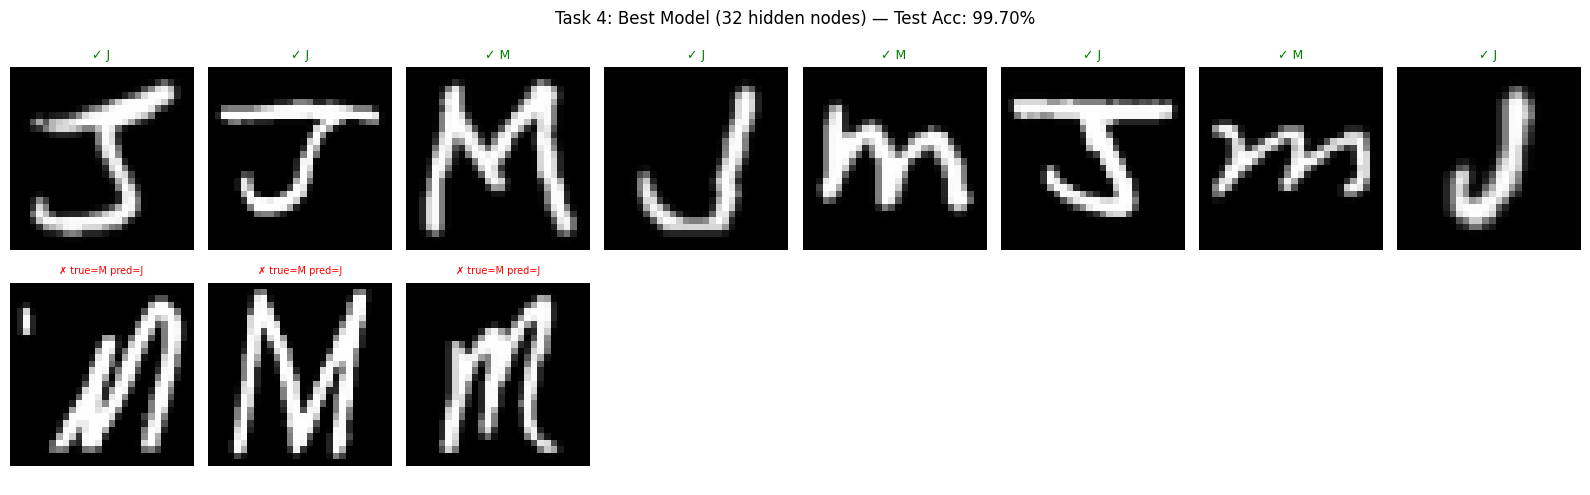

In [69]:
# ---- Visualise correct and incorrect predictions (no blank plots) ----
correct_idxs   = np.where(best_t4['test_preds'] == y4_test)[0][:8]
incorrect_idxs = np.where(best_t4['test_preds'] != y4_test)[0]

n_correct   = len(correct_idxs)
n_incorrect = len(incorrect_idxs)
n_cols      = max(n_correct, n_incorrect)

fig, axes = plt.subplots(2, n_cols, figsize=(2 * n_cols, 5))

# Top row: correct predictions
for j in range(n_cols):
    if j < n_correct:
        idx = correct_idxs[j]
        axes[0, j].imshow(x_flat[test_idx[idx]].reshape(28, 28), cmap="gray")
        axes[0, j].set_title(f"✓ {letter_map[int(y4_test[idx])]}", color="green", fontsize=9)
    axes[0, j].axis("off")

# Bottom row: incorrect predictions
for j in range(n_cols):
    if j < n_incorrect:
        idx = incorrect_idxs[j]
        axes[1, j].imshow(x_flat[test_idx[idx]].reshape(28, 28), cmap="gray")
        axes[1, j].set_title(
            f"✗ true={letter_map[int(y4_test[idx])]} pred={letter_map[int(best_t4['test_preds'][idx])]}",
            color="red", fontsize=7
        )
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=10, color="green")
axes[1, 0].set_ylabel("Wrong",   fontsize=10, color="red")
plt.suptitle(f"Task 4: Best Model ({best_t4['n_hidden']} hidden nodes) — Test Acc: {best_t4['test_acc']:.2%}")
plt.tight_layout()
plt.show()